## Purpose of this project

This project builds a serverless ETL pipeline for HDB's public Resale Flat Prices dataset, covering January 2012 to December 2016. It ingests resale transaction records (via an automated data.gov.sg pull or a manual upload), validates them against the required business rules, derives and hashes a Resale Identifier, and lands the result in governed Iceberg tables that downstream analysts and tools can query directly. The whole run is event-driven end to end, notifies a subscriber by email on every success or failure, and runs entirely on AWS-managed serverless services — nothing here needs a server to be provisioned or kept running.

## Deploying the pipeline

The AWS infrastructure for this pipeline can be provisioned in one of two ways:

1. **Run the CI/CD pipeline** — push to the `main` branch. GitHub Actions automatically lints the changed scripts, deploys them to S3, and regenerates/updates the Step Functions state machine so it always matches what's in source control.
2. **Run it locally** — from a bash shell, run the setup script directly. It provisions every resource in one pass: the S3 buckets, the Glue Data Catalog and jobs, the IAM roles, the Step Functions state machine, the SNS notification topic, and the EventBridge rules that make the whole thing event-driven.

In [ ]:
%%bash
bash setup.sh

`setup.sh` is idempotent — running it again when the infrastructure already exists is harmless, so it's safe to re-run after a partial failure or a config change.

To tear everything down cleanly (for a fresh test cycle, or to avoid ongoing AWS costs), run:

In [ ]:
%%bash
bash tear_down.sh

## Ingestion types

Once the infrastructure is deployed, data can enter the pipeline two ways — both are treated identically by every stage that follows, neither is a "lesser" path:

1. **Automated ingestion** — pulls the full "Resale Flat Prices" collection from data.gov.sg's public API and lands it in S3. It can be run directly from bash, or left to fire on its own schedule/trigger:

In [ ]:
%%bash
aws glue start-job-run \
    --job-name hdb-job-1-ingestion-to-source \
    --profile sujen \
    --region us-east-1

When this finishes successfully, an event rule detects it and automatically kicks off the rest of the pipeline — no manual trigger needed after this point.

2. **Manual upload** — drop a CSV directly into the manual-upload location in the source bucket. A separate event rule watches this location and starts the same pipeline immediately, without needing the automated pull to run first:

In [ ]:
%%bash
aws s3 cp my_file.csv \
    s3://mission-hdb-eventdriven-source/resale-flat-prices-manual-upload/my_file.csv \
    --profile sujen \
    --region us-east-1

Both routes converge on the same first processing step, so a manually-uploaded file is combined with any automated data and carried through every remaining stage exactly the same way.

## End-to-end serverless architecture

Nothing in this pipeline runs on a server you provision or manage — every piece is a fully-managed AWS service that scales automatically and only costs money while it's actually doing work. See the diagram below for the full flow.

## Email subscription — subscribe, confirm, then receive

Before any run notification can actually reach an inbox, that address has to be subscribed to the SNS notification topic and the subscription confirmed. This is a one-time step per email address.

**1. Subscribe an email address to the topic:**

In [ ]:
%%bash
python sns_subscription_setup.py --region us-east-1 --email you@example.com

**2. Confirm the subscription** — AWS sends an email titled "AWS Notification - Subscription Confirmation" to that address. Open it and click **Confirm subscription**. Until this is done, the subscription sits in `PendingConfirmation` and SNS silently drops every message sent to it — `Publish` calls still succeed, nothing actually arrives.

**3. Verify the subscription is confirmed:**

In [ ]:
%%bash
aws sns list-subscriptions-by-topic \
    --topic-arn arn:aws:sns:us-east-1:<ACCOUNT_ID>:hdb-eventdriven-notifications \
    --profile sujen \
    --region us-east-1

Look at the `SubscriptionArn` field in the output — a real ARN means it's confirmed and ready to receive; `PendingConfirmation` means step 2 hasn't been completed yet.

## Email notifications — success or failure

An email is sent automatically at the end of every run, regardless of outcome:

- **On success** — a summary email confirms the run completed, listing what was processed at each stage.
- **On failure** — as soon as any stage fails, the workflow stops that path immediately and sends a failure email naming which stage failed and why, instead of continuing silently or failing without any notice.

Either way, no one needs to check the AWS console to know how a run went — the result lands directly in the inbox of whoever is subscribed to the notification topic.

## Metadata-driven

Every run is driven by metadata, not hardcoded logic:

- Pipeline parameters (which tables exist, whether a stage does a full reload or an incremental merge, lookback windows, etc.) are read live from metadata tables rather than baked into the code — changing behaviour is a metadata change, not a code change.
- A **context** is created at the start of a run and updated as it progresses, capturing what actually happened at each stage.
- That context is what the final email summary is built from — the notification reflects the real recorded outcome of the run, not just "it finished.

## Analytics access

The same data this pipeline produces is immediately queryable by others, with no separate export step:

**AWS Glue Data Catalog → Amazon Athena → Tableau (or any BI/analytics tool)**

Views can be created on top of the Iceberg tables in the Glue Data Catalog, then queried directly through Athena — giving analysts, data scientists, or a BI tool like Tableau governed, read-only access to the data without needing their own copy or a separate pipeline.

## Overall pipeline characteristics

- **Idempotent** — rerunning a stage with the same input produces the same end state, never duplicate data
- **Scalable** — every component (Glue, Step Functions, Athena, S3, Lambda) is serverless and scales automatically with data volume
- **Supports full and incremental load** — each table's load strategy (full reload vs. merge/upsert) is a metadata setting, not hardcoded per stage
- **Robust** — validation and quarantine rules mean bad records are isolated, not silently dropped or allowed to break a run
- **Logging** — every run is recorded with what went in, what came out, and what was rejected, at every stage
- **Retry & recovery** — transient AWS-side failures are retried automatically where safe to do so, and a failed run's exact failure point is captured and emailed immediately rather than failing silently
- **Apache Iceberg table format** — every stage's table gets schema evolution (new columns can be added without rewriting existing data), time travel (querying a table as of an earlier snapshot), and partitioning (organizing data on disk for faster, cheaper queries) — all for free from the table format itself, not custom-built

## Architecture diagram

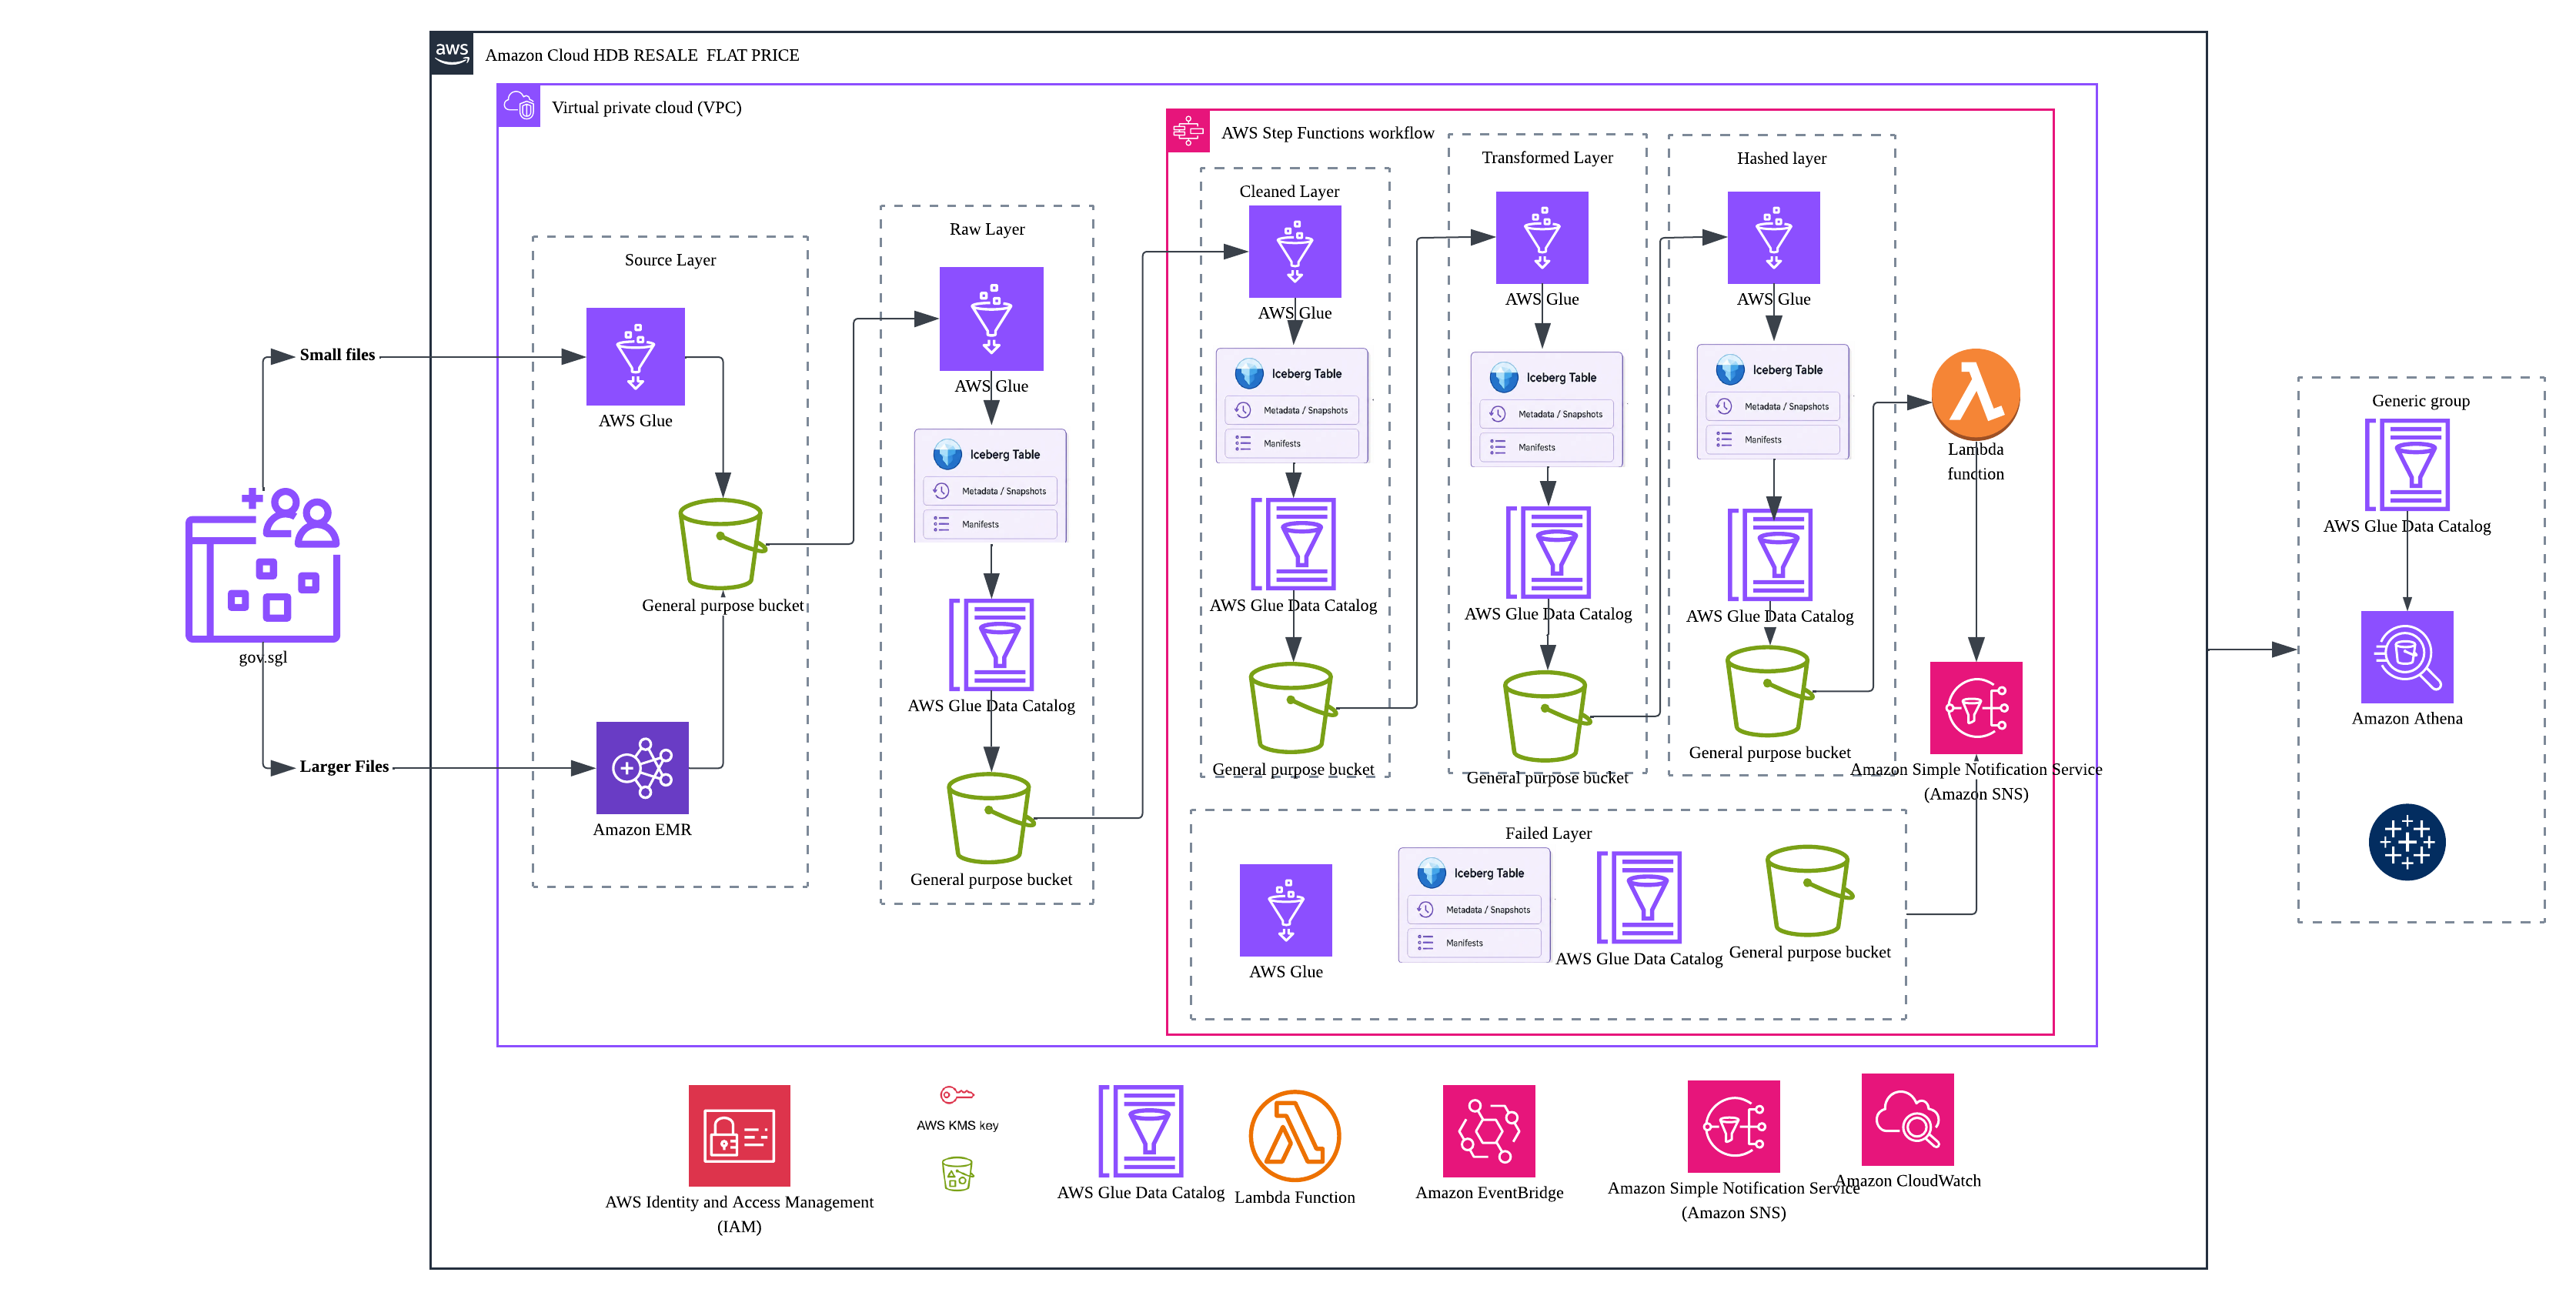